In [72]:
import torch
from torch import nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

In [73]:
# код для генерации взят из Стэнфордсокго курса:
# http://cs231n.github.io/neural-networks-case-study/#linear

N = 100
D = 2
K = 3
X = np.zeros((N * K, D))
y = np.zeros(N * K, dtype='uint8')

for j in range(K):
    ix = range(N * j,N * (j + 1))
    r = np.linspace(0.0, 1, N)
    t = np.linspace(j * 4, (j + 1) * 4,N) + np.random.randn(N) * 0.2 # theta
    X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
    y[ix] = j

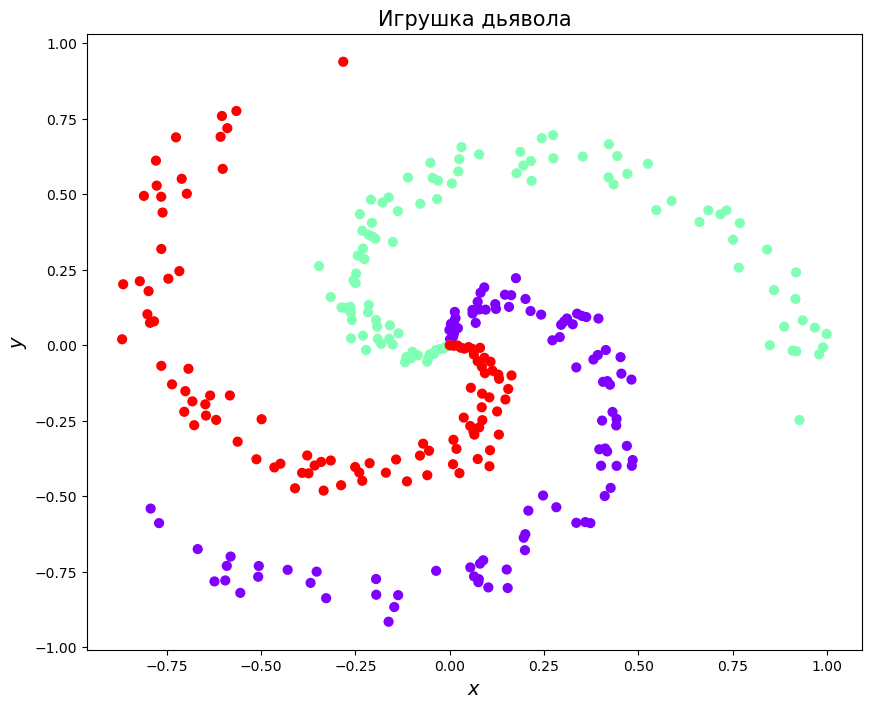

In [74]:
# Отрисовочная магия, снова взято из:
# http://cs231n.github.io/neural-networks-case-study/#linear

plt.figure(figsize=(10, 8))

plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.rainbow)

plt.title('Игрушка дьявола', fontsize=15)
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.show();

In [75]:
X = torch.FloatTensor(X)
y = torch.LongTensor(y)

In [76]:
D_in, H, D_out = 2, 100, 3

two_layer_net = nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
    torch.nn.Softmax()
)

In [77]:
# короче делаем то же самое но нормально чтобы посмотреть параметры сетки
class MyModule(nn.Module):
    def __init__(self):
        super(MyModule, self).__init__()
        self.f_lin = nn.Linear(D_in, H)
        self.s_lin = nn.Linear(H, D_out)

    def forward(self, X):
        X = F.relu(self.f_lin(X))
        return F.softmax(self.s_lin(X))

In [78]:
model = MyModule()

loss_fn = nn.CrossEntropyLoss()

optim = torch.optim.Adam(model.parameters(), 1e-1)

In [79]:
list(model.parameters())

[Parameter containing:
 tensor([[-5.2573e-01,  6.2106e-01],
         [-3.7821e-02, -4.3168e-01],
         [ 6.4814e-01, -6.3741e-01],
         [-6.2822e-01, -3.8199e-01],
         [ 2.0005e-01, -5.1961e-01],
         [ 1.2282e-01,  1.4740e-01],
         [-3.5205e-01, -1.2557e-01],
         [ 4.8804e-01, -3.6114e-01],
         [-6.1393e-01, -2.6871e-01],
         [-4.1311e-01,  1.5356e-01],
         [ 5.0049e-01,  6.0802e-01],
         [-2.4670e-01,  5.7003e-01],
         [-6.2153e-01,  6.4529e-01],
         [-6.7587e-01, -5.5640e-01],
         [ 2.4011e-01,  4.8129e-01],
         [-1.2286e-01,  7.0398e-01],
         [-4.5217e-01,  5.0959e-01],
         [-1.0360e-01,  4.1365e-01],
         [-7.0103e-02,  8.6330e-02],
         [ 8.8142e-02, -6.6207e-01],
         [ 1.0713e-01,  2.6766e-01],
         [-7.0179e-01,  2.7078e-01],
         [-5.9035e-01, -1.7577e-01],
         [-8.6993e-02, -6.3266e-02],
         [-3.4100e-02,  4.1406e-01],
         [-1.5821e-01, -2.5694e-01],
         [-6.63

In [80]:
losses = []
def train(model, X, y, loss_fn, optim):
    for t in range(100):
        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        losses.append(loss.item())

        loss.backward()
        optim.step()
        optim.zero_grad()
    return model

In [81]:
model = train(model, X, y, loss_fn, optim)

C:\Users\maxim\AppData\Local\Temp\ipykernel_3408\3254493444.py:10: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(self.s_lin(X))


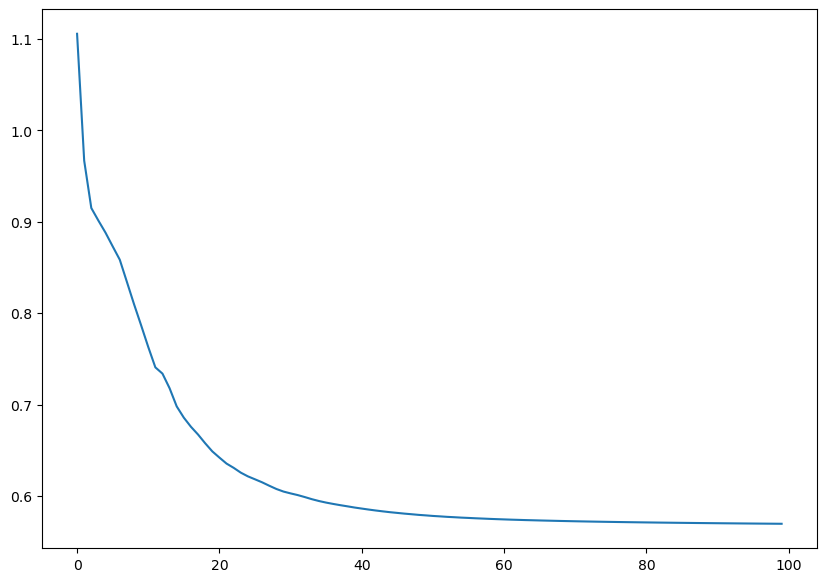

In [82]:
fig = plt.figure(figsize=(10,7))

plt.plot(losses)

In [83]:
list(model.parameters())

[Parameter containing:
 tensor([[-3.5657e+00,  3.5145e+00],
         [ 2.7404e+00, -6.0057e-01],
         [ 1.7062e+00, -3.3105e+00],
         [ 1.3916e-01, -5.6302e-01],
         [-2.7992e+00, -2.7018e+00],
         [-4.7769e-01, -4.5311e-01],
         [-3.5205e-01, -1.2557e-01],
         [ 1.1499e+00, -9.1415e-01],
         [-2.5649e+00,  1.1536e+00],
         [-2.0247e+00, -1.1087e+00],
         [-3.6240e-01,  3.3826e+00],
         [-1.9674e+00,  3.4276e+00],
         [-2.8594e-02,  5.4352e-01],
         [-4.5254e+00, -3.1481e+00],
         [ 2.8207e+00,  1.9932e+00],
         [-3.3894e+00,  6.7812e-01],
         [-2.7835e+00,  1.7928e+00],
         [-1.0360e-01,  4.1365e-01],
         [-9.2339e-04, -2.1669e-01],
         [ 6.8845e-01, -6.1575e-02],
         [ 1.0713e-01,  2.6766e-01],
         [-2.7932e+00,  2.0078e+00],
         [-3.2969e+00, -1.1196e+00],
         [-8.6993e-02, -6.3266e-02],
         [-3.4100e-02,  4.1406e-01],
         [ 1.4560e+00, -7.6997e-01],
         [-3.34

In [100]:
class MyModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layers = [nn.Linear(D_in, H), nn.Linear(H, D_out)]
        self.my_useless_bias = torch.ones(1, H)
        self.more_of_my_useless_biases = [
            torch.ones(1, H),
            torch.ones(1, H),
            torch.ones(1, H)
        ]

    def forward(self, X):
        X = F.relu(self.linear_layers[0](X))
        X += self.my_useless_bias
        return F.softmax(self.linear_layers[1](X))

In [102]:
model = MyModule()
list(model.parameters())

[]

In [104]:
# исправим это
class MyModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layers = nn.ModuleList([nn.Linear(D_in, H), nn.Linear(H, D_out)])
        self.my_useless_bias = nn.Parameter(torch.ones(1, H))
        self.more_of_my_useless_biases = nn.ParameterList([
            torch.ones(1, H),
            torch.ones(1, H),
            torch.ones(1, H)
        ])

    def forward(self, X):
        X = F.relu(self.linear_layers[0](X))
        X += self.my_useless_bias
        for b in self.more_of_my_useless_biases:
            X += b
        return F.softmax(self.linear_layers[1](X))

In [106]:
model = MyModule()
list(model.parameters())

[Parameter containing:
 tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]], requires_grad=True),
 Parameter containing:
 tensor([[ 0.6752, -0.4335],
         [ 0.4488, -0.7038],
         [ 0.1298, -0.2303],
         [ 0.6571,  0.0050],
         [ 0.5264,  0.2655],
         [ 0.3275, -0.4789],
         [-0.2954, -0.3017],
         [-0.4669, -0.3413],
         [ 0.5309, -0.5017],
         [ 0.1108,  0.5725],
         [-0.6644, -0.3663],
         [ 0.5914, -0.1035],
         [ 0.5817,  0.1706],
         [ 0.1162, -0.5306],
         [-0.0889,  0.3266],
         [-0.4008,  0.2353],
       